### PathVQA Data Analysis

This code will analyze raw PathVQA data and find how much data was filtered based on non-pathology images as well as containing less number of words

In [1]:
import sys
from PIL import Image
import pandas as pd
import os
import pickle
from collections import Counter
import numpy as np
import shutil
import seaborn as sns
import matplotlib.pyplot as plt

#### Raw Data Paths

In [2]:
pvqa_data_path = "/data/mn27889/pvqa"
pvqa_images = os.path.join(pvqa_data_path, "images")
pvqa_qas = os.path.join(pvqa_data_path, "qas")

#### Paths of PathVQA images after filtering down the histopathology images

In [3]:
pvqa_histo_data_path = "/data/mn27889/path-open-data/pathvqa-histopathology"
pvqa_histo_images = os.path.join(pvqa_histo_data_path, "images")
pvqa_histo_qas = os.path.join(pvqa_histo_data_path, "qas")

#### 1. Analyzing the images/qas from `RAW` dataset

In [4]:
pvqa_subset_list = ["train", "test", "val"]
pvqa_image_list_combined_raw = []
pvqa_qas_close_ended_combined_raw = []
pvqa_qas_open_ended_combined_raw = []
pvqa_close_ended_questions_words_5_combined_raw = []
pvqa_open_ended_questions_words_5_combined_raw = []
pvqa_open_ended_answers_words_5_combined_raw = []
pvqa_close_ended_questions_words_10_combined_raw = []
pvqa_open_ended_questions_words_10_combined_raw = []
pvqa_open_ended_answers_words_10_combined_raw = []
pvqa_raw_ques_first_word_combined_raw = []

for pvqa_subset in pvqa_subset_list:
    qas_filename = f"{pvqa_subset}_qa.pkl"
    
    pvqa_images_subset_path = os.path.join(pvqa_images, pvqa_subset)
    pvqa_qas_subset_path = os.path.join(pvqa_qas, pvqa_subset)
    
    pvqa_image_list = os.listdir(pvqa_images_subset_path)
    pvqa_image_list_combined_raw.extend(pvqa_image_list)
    print(f"Number of images in Raw {pvqa_subset} subset: {len(pvqa_image_list)}")
    
    qas_file_path = os.path.join(pvqa_qas_subset_path, qas_filename)
    with open(qas_file_path, 'rb') as file:
        pvqa_qas_subset = pickle.load(file)

    pvqa_qas_close_ended = [sample for sample in pvqa_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
    pvqa_qas_open_ended = [sample for sample in pvqa_qas_subset if sample not in pvqa_qas_close_ended]
    pvqa_qas_close_ended_combined_raw.extend(pvqa_qas_close_ended)
    pvqa_qas_open_ended_combined_raw.extend(pvqa_qas_open_ended)
    print(f'Number of Raw {pvqa_subset} Close-Ended Questions:', len(pvqa_qas_close_ended))
    print(f'Number of Raw {pvqa_subset} Open-Ended Questions:', len(pvqa_qas_open_ended))
    
    pvqa_close_ended_questions_words_5 = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 5]
    pvqa_open_ended_questions_words_5 = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 5]
    pvqa_open_ended_answers_words_5 = [sample for sample in pvqa_qas_open_ended if len(sample['answer'].split()) >= 5]
    pvqa_close_ended_questions_words_5_combined_raw.extend(pvqa_close_ended_questions_words_5)
    pvqa_open_ended_questions_words_5_combined_raw.extend(pvqa_open_ended_questions_words_5)
    pvqa_open_ended_answers_words_5_combined_raw.extend(pvqa_open_ended_answers_words_5)
    print(f'Number of Raw {pvqa_subset} Close-Ended Questions (Words >= 5):', len(pvqa_close_ended_questions_words_5))
    print(f'Number of Raw {pvqa_subset} Open-Ended Questions (Words >= 5):', len(pvqa_open_ended_questions_words_5))
    print(f'Number of Raw {pvqa_subset} Open-Ended Answers (Words >= 5):', len(pvqa_open_ended_answers_words_5))


    pvqa_close_ended_questions_words_10 = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 10]
    pvqa_open_ended_questions_words_10 = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 10]
    pvqa_open_ended_answers_words_10 = [sample for sample in pvqa_qas_open_ended if len(sample['answer'].split()) >= 10]
    pvqa_close_ended_questions_words_10_combined_raw.extend(pvqa_close_ended_questions_words_10)
    pvqa_open_ended_questions_words_10_combined_raw.extend(pvqa_open_ended_questions_words_10)
    pvqa_open_ended_answers_words_10_combined_raw.extend(pvqa_open_ended_answers_words_10)
    print(f'Number of Raw {pvqa_subset} Close-Ended Questions (Words >= 10):', len(pvqa_close_ended_questions_words_10))
    print(f'Number of Raw {pvqa_subset} Open-Ended Questions (Words >= 10):', len(pvqa_open_ended_questions_words_10))
    print(f'Number of Raw {pvqa_subset} Open-Ended Answers (Words >= 10):', len(pvqa_open_ended_answers_words_10))
    
    pvqa_raw_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_qas_open_ended]
    first_word_counts = Counter(pvqa_raw_ques_first_word)
    pvqa_raw_ques_first_word_combined_raw.extend(pvqa_raw_ques_first_word)
    print(f'First Word in Raw {pvqa_subset} Open-Ended Questions: ', first_word_counts)

    print("--------------------------------------------------")

print("---------------------Overall----------------------")
print(f"Number of images in Raw dataset: {len(pvqa_image_list_combined_raw)}")
print(f'Number of Raw Close-Ended Questions:', len(pvqa_qas_close_ended_combined_raw))
print(f'Number of Raw Open-Ended Questions:', len(pvqa_qas_open_ended_combined_raw))
print(f'Number of Raw Close-Ended Questions (Words >= 5):', len(pvqa_close_ended_questions_words_5_combined_raw))
print(f'Number of Raw Open-Ended Questions (Words >= 5):', len(pvqa_open_ended_questions_words_5_combined_raw))
print(f'Number of Raw Open-Ended Answers (Words >= 5):', len(pvqa_open_ended_answers_words_5_combined_raw))
print(f'Number of Raw Close-Ended Questions (Words >= 10):', len(pvqa_close_ended_questions_words_10_combined_raw))
print(f'Number of Raw Open-Ended Questions (Words >= 10):', len(pvqa_open_ended_questions_words_10_combined_raw))
print(f'Number of Raw Open-Ended Answers (Words >= 10):', len(pvqa_open_ended_answers_words_10_combined_raw))
first_word_counts_combined_raw = Counter(pvqa_raw_ques_first_word_combined_raw)
print(f'First Word in Raw Open-Ended Questions: ', first_word_counts_combined_raw)

Number of images in Raw train subset: 3021
Number of Raw train Close-Ended Questions: 9806
Number of Raw train Open-Ended Questions: 9949
Number of Raw train Close-Ended Questions (Words >= 5): 5913
Number of Raw train Open-Ended Questions (Words >= 5): 4595
Number of Raw train Open-Ended Answers (Words >= 5): 1461
Number of Raw train Close-Ended Questions (Words >= 10): 2589
Number of Raw train Open-Ended Questions (Words >= 10): 977
Number of Raw train Open-Ended Answers (Words >= 10): 402
First Word in Raw train Open-Ended Questions:  Counter({'what': 8079, 'where': 1316, 'how': 428, 'why': 71, 'when': 31, 'whose': 5, 'the': 4, 'there': 3, 'two': 2, 'one': 2, 'who': 2, 'impaired': 1, 'acute': 1, 'infiltration': 1, 'sectioned': 1, 'are': 1, 'is': 1})
--------------------------------------------------
Number of images in Raw test subset: 991
Number of Raw test Close-Ended Questions: 3391
Number of Raw test Open-Ended Questions: 3370
Number of Raw test Close-Ended Questions (Words >= 5

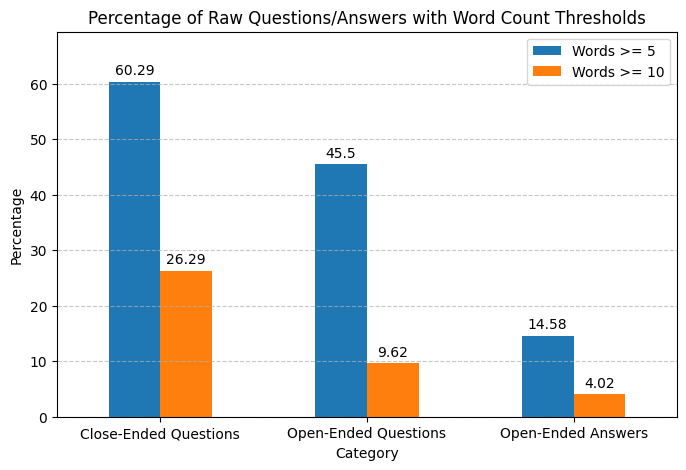

In [5]:
pvqa_close_ended_questions_words_5_percent_raw = round((len(pvqa_close_ended_questions_words_5_combined_raw) / len(pvqa_qas_close_ended_combined_raw)) * 100, 2)
pvqa_open_ended_questions_words_5_percent_raw = round((len(pvqa_open_ended_questions_words_5_combined_raw) / len(pvqa_qas_open_ended_combined_raw)) * 100, 2)
pvqa_open_ended_answers_words_5_percent_raw = round((len(pvqa_open_ended_answers_words_5_combined_raw) / len(pvqa_qas_open_ended_combined_raw)) * 100, 2)

pvqa_close_ended_questions_words_10_percent_raw = round((len(pvqa_close_ended_questions_words_10_combined_raw) / len(pvqa_qas_close_ended_combined_raw)) * 100, 2)
pvqa_open_ended_questions_words_10_percent_raw = round((len(pvqa_open_ended_questions_words_10_combined_raw) / len(pvqa_qas_open_ended_combined_raw)) * 100, 2)
pvqa_open_ended_answers_words_10_percent_raw = round((len(pvqa_open_ended_answers_words_10_combined_raw) / len(pvqa_qas_open_ended_combined_raw)) * 100, 2)

df = pd.DataFrame({
    'Words >= 5': [pvqa_close_ended_questions_words_5_percent_raw, pvqa_open_ended_questions_words_5_percent_raw, pvqa_open_ended_answers_words_5_percent_raw],
    'Words >= 10': [pvqa_close_ended_questions_words_10_percent_raw, pvqa_open_ended_questions_words_10_percent_raw, pvqa_open_ended_answers_words_10_percent_raw],
    'Category': ['Close-Ended Questions', 'Open-Ended Questions', 'Open-Ended Answers']
})

ax = df.plot(x='Category', y=['Words >= 5', 'Words >= 10'], kind='bar', figsize=(8, 5), title='Percentage of Raw Questions/Answers with Word Count Thresholds', ylabel='Percentage')
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.margins(0.15)
plt.xticks(rotation=0)
plt.show()

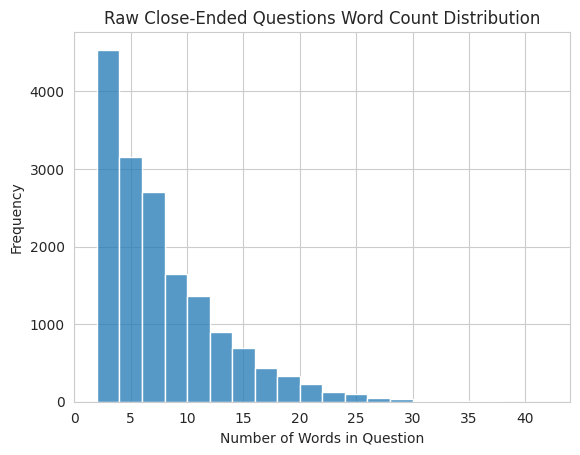

In [6]:
pvqa_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_close_ended_combined_raw]
sns.set_style("whitegrid")
sns.histplot(pvqa_close_ended_questions_words_distrib, bins=20)
plt.title(f'Raw Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


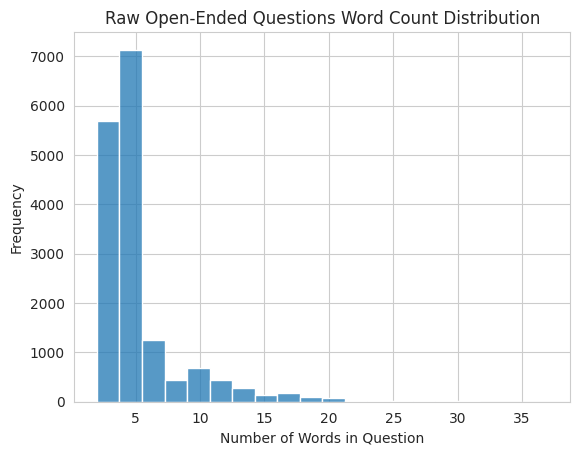

In [7]:
pvqa_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_open_ended_combined_raw]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_questions_words_distrib, bins=20)
plt.title(f'Raw Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

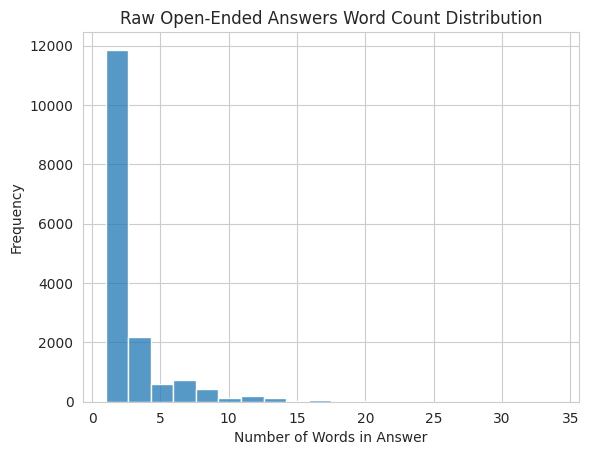

In [8]:
pvqa_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_qas_open_ended_combined_raw]
sns.set_style("whitegrid")
sns.histplot(pvqa_open_ended_answers_words_distrib, bins=20)
plt.title(f'Raw Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

##### Histo

In [9]:
pvqa_subset_list = ["train", "test", "val"]
pvqa_image_list_combined_histo = []
pvqa_qas_close_ended_combined_histo = []
pvqa_qas_open_ended_combined_histo = []
pvqa_close_ended_questions_words_5_combined_histo = []
pvqa_open_ended_questions_words_5_combined_histo = []
pvqa_open_ended_answers_words_5_combined_histo = []
pvqa_close_ended_questions_words_10_combined_histo = []
pvqa_open_ended_questions_words_10_combined_histo = []
pvqa_open_ended_answers_words_10_combined_histo = []
pvqa_histo_ques_first_word_combined_histo = []

for pvqa_subset in pvqa_subset_list:
    qas_filename = f"{pvqa_subset}_qa.pkl"
    
    pvqa_images_subset_path = os.path.join(pvqa_histo_images, pvqa_subset)
    pvqa_qas_subset_path = os.path.join(pvqa_histo_qas, pvqa_subset)
    
    pvqa_image_list = os.listdir(pvqa_images_subset_path)
    pvqa_image_list_combined_histo.extend(pvqa_image_list)
    print(f"Number of images in Histo {pvqa_subset} subset: {len(pvqa_image_list)}")
    
    qas_file_path = os.path.join(pvqa_qas_subset_path, qas_filename)
    with open(qas_file_path, 'rb') as file:
        pvqa_qas_subset = pickle.load(file)

    pvqa_qas_close_ended = [sample for sample in pvqa_qas_subset if sample['answer'].lower() == 'yes' or sample['answer'].lower() == 'no']
    pvqa_qas_open_ended = [sample for sample in pvqa_qas_subset if sample not in pvqa_qas_close_ended]
    pvqa_qas_close_ended_combined_histo.extend(pvqa_qas_close_ended)
    pvqa_qas_open_ended_combined_histo.extend(pvqa_qas_open_ended)
    print(f'Number of Histo {pvqa_subset} Close-Ended Questions:', len(pvqa_qas_close_ended))
    print(f'Number of Histo {pvqa_subset} Open-Ended Questions:', len(pvqa_qas_open_ended))
    
    pvqa_close_ended_questions_words_5 = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 5]
    pvqa_open_ended_questions_words_5 = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 5]
    pvqa_open_ended_answers_words_5 = [sample for sample in pvqa_qas_open_ended if len(sample['answer'].split()) >= 5]
    pvqa_close_ended_questions_words_5_combined_histo.extend(pvqa_close_ended_questions_words_5)
    pvqa_open_ended_questions_words_5_combined_histo.extend(pvqa_open_ended_questions_words_5)
    pvqa_open_ended_answers_words_5_combined_histo.extend(pvqa_open_ended_answers_words_5)
    print(f'Number of Histo {pvqa_subset} Close-Ended Questions (Words >= 5):', len(pvqa_close_ended_questions_words_5))
    print(f'Number of Histo {pvqa_subset} Open-Ended Questions (Words >= 5):', len(pvqa_open_ended_questions_words_5))
    print(f'Number of Histo {pvqa_subset} Open-Ended Answers (Words >= 5):', len(pvqa_open_ended_answers_words_5))
    
    pvqa_close_ended_questions_words_10 = [sample for sample in pvqa_qas_close_ended if len(sample['question'].split()) >= 10]
    pvqa_open_ended_questions_words_10 = [sample for sample in pvqa_qas_open_ended if len(sample['question'].split()) >= 10]
    pvqa_open_ended_answers_words_10 = [sample for sample in pvqa_qas_open_ended if len(sample['answer'].split()) >= 10]
    pvqa_close_ended_questions_words_10_combined_histo.extend(pvqa_close_ended_questions_words_10)
    pvqa_open_ended_questions_words_10_combined_histo.extend(pvqa_open_ended_questions_words_10)
    pvqa_open_ended_answers_words_10_combined_histo.extend(pvqa_open_ended_answers_words_10)
    print(f'Number of Histo {pvqa_subset} Close-Ended Questions (Words >= 10):', len(pvqa_close_ended_questions_words_10))
    print(f'Number of Histo {pvqa_subset} Open-Ended Questions (Words >= 10):', len(pvqa_open_ended_questions_words_10))
    print(f'Number of Histo {pvqa_subset} Open-Ended Answers (Words >= 10):', len(pvqa_open_ended_answers_words_10))

    pvqa_histo_ques_first_word = [sample['question'].split()[0].lower() for sample in pvqa_qas_open_ended]
    first_word_counts = Counter(pvqa_histo_ques_first_word)
    pvqa_histo_ques_first_word_combined_histo.extend(pvqa_histo_ques_first_word)
    print(f'First Word in Histo {pvqa_subset} Open-Ended Questions: ', first_word_counts)
    print("--------------------------------------------------")

print("---------------------Overall----------------------")
print(f"Number of images in Histo dataset: {len(pvqa_image_list_combined_histo)}")
print(f'Number of Histo Close-Ended Questions:', len(pvqa_qas_close_ended_combined_histo))
print(f'Number of Histo Open-Ended Questions:', len(pvqa_qas_open_ended_combined_histo))
print(f'Number of Histo Close-Ended Questions (Words >= 5):', len(pvqa_close_ended_questions_words_5_combined_histo))
print(f'Number of Histo Open-Ended Questions (Words >= 5):', len(pvqa_open_ended_questions_words_5_combined_histo))
print(f'Number of Histo Open-Ended Answers (Words >= 5):', len(pvqa_open_ended_answers_words_5_combined_histo))
print(f'Number of Histo Close-Ended Questions (Words >= 10):', len(pvqa_close_ended_questions_words_10_combined_histo))
print(f'Number of Histo Open-Ended Questions (Words >= 10):', len(pvqa_open_ended_questions_words_10_combined_histo))
print(f'Number of Histo Open-Ended Answers (Words >= 10):', len(pvqa_open_ended_answers_words_10_combined_histo))
first_word_counts_combined_histo = Counter(pvqa_histo_ques_first_word_combined_histo)
print(f'First Word in Histo Open-Ended Questions: ', first_word_counts_combined_histo)


Number of images in Histo train subset: 896
Number of Histo train Close-Ended Questions: 2751
Number of Histo train Open-Ended Questions: 2644
Number of Histo train Close-Ended Questions (Words >= 5): 1785
Number of Histo train Open-Ended Questions (Words >= 5): 1348
Number of Histo train Open-Ended Answers (Words >= 5): 421
Number of Histo train Close-Ended Questions (Words >= 10): 852
Number of Histo train Open-Ended Questions (Words >= 10): 358
Number of Histo train Open-Ended Answers (Words >= 10): 97
First Word in Histo train Open-Ended Questions:  Counter({'what': 2183, 'where': 305, 'how': 110, 'why': 22, 'when': 13, 'whose': 4, 'the': 2, 'there': 2, 'acute': 1, 'are': 1, 'is': 1})
--------------------------------------------------
Number of images in Histo test subset: 309
Number of Histo test Close-Ended Questions: 995
Number of Histo test Open-Ended Questions: 890
Number of Histo test Close-Ended Questions (Words >= 5): 640
Number of Histo test Open-Ended Questions (Words >= 

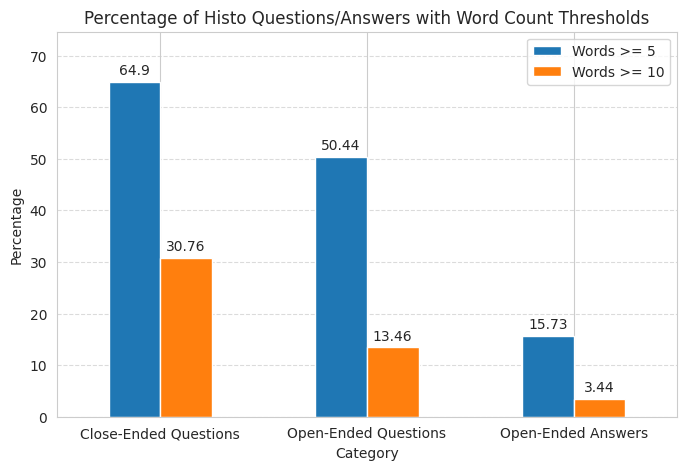

In [10]:
pvqa_close_ended_questions_words_5_percent_histo = round((len(pvqa_close_ended_questions_words_5_combined_histo) / len(pvqa_qas_close_ended_combined_histo)) * 100, 2)
pvqa_open_ended_questions_words_5_percent_histo = round((len(pvqa_open_ended_questions_words_5_combined_histo) / len(pvqa_qas_open_ended_combined_histo)) * 100, 2)
pvqa_open_ended_answers_words_5_percent_histo = round((len(pvqa_open_ended_answers_words_5_combined_histo) / len(pvqa_qas_open_ended_combined_histo)) * 100, 2)

pvqa_close_ended_questions_words_10_percent_histo = round((len(pvqa_close_ended_questions_words_10_combined_histo) / len(pvqa_qas_close_ended_combined_histo)) * 100, 2)
pvqa_open_ended_questions_words_10_percent_histo = round((len(pvqa_open_ended_questions_words_10_combined_histo) / len(pvqa_qas_open_ended_combined_histo)) * 100, 2)
pvqa_open_ended_answers_words_10_percent_histo = round((len(pvqa_open_ended_answers_words_10_combined_histo) / len(pvqa_qas_open_ended_combined_histo)) * 100, 2)

df = pd.DataFrame({
    'Words >= 5': [pvqa_close_ended_questions_words_5_percent_histo, pvqa_open_ended_questions_words_5_percent_histo, pvqa_open_ended_answers_words_5_percent_histo],
    'Words >= 10': [pvqa_close_ended_questions_words_10_percent_histo, pvqa_open_ended_questions_words_10_percent_histo, pvqa_open_ended_answers_words_10_percent_histo],
    'Category': ['Close-Ended Questions', 'Open-Ended Questions', 'Open-Ended Answers']
})

ax = df.plot(x='Category', y=['Words >= 5', 'Words >= 10'], kind='bar', figsize=(8, 5), title='Percentage of Histo Questions/Answers with Word Count Thresholds', ylabel='Percentage')
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.margins(0.15)
plt.xticks(rotation=0)
plt.show()

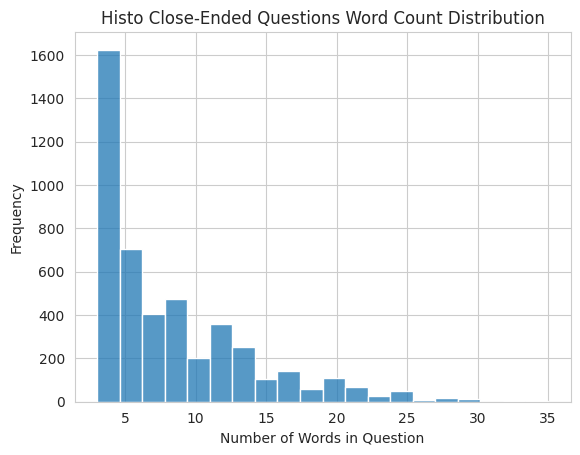

In [11]:
pvqa_histo_close_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_close_ended_combined_histo]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_close_ended_questions_words_distrib, bins=20)
plt.title(f'Histo Close-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()


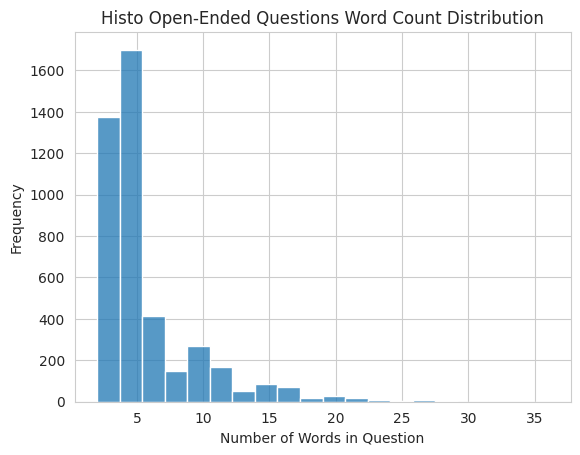

In [12]:
pvqa_histo_open_ended_questions_words_distrib = [len(sample['question'].split()) for sample in pvqa_qas_open_ended_combined_histo]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_questions_words_distrib, bins=20)
plt.title(f'Histo Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

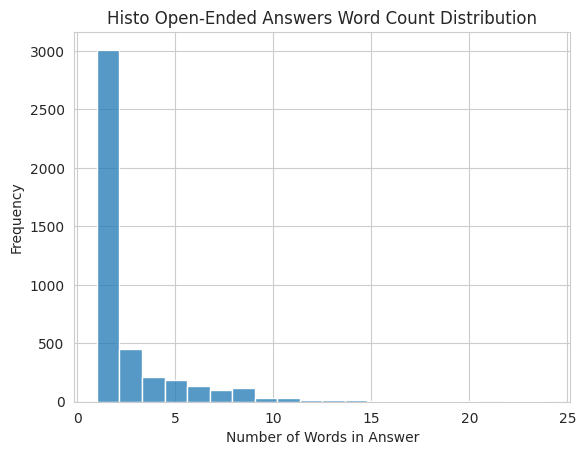

In [13]:
pvqa_histo_open_ended_answers_words_distrib = [len(sample['answer'].split()) for sample in pvqa_qas_open_ended_combined_histo]
sns.set_style("whitegrid")
sns.histplot(pvqa_histo_open_ended_answers_words_distrib, bins=20)
plt.title(f'Histo Open-Ended Answers Word Count Distribution')
plt.xlabel('Number of Words in Answer')
plt.ylabel('Frequency')
plt.show()

#### Generating a side-by-side graph for Raw and Histo Dataset

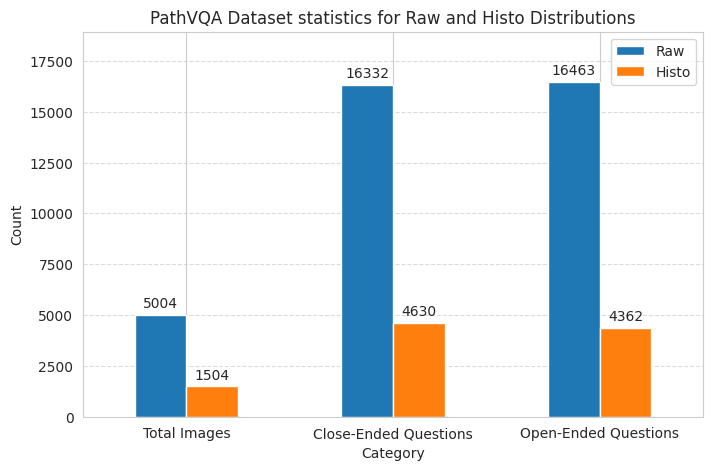

In [16]:
df = pd.DataFrame({
    'Raw': [len(pvqa_image_list_combined_raw), len(pvqa_qas_close_ended_combined_raw), len(pvqa_qas_open_ended_combined_raw)],
    'Histo': [len(pvqa_image_list_combined_histo), len(pvqa_qas_close_ended_combined_histo), len(pvqa_qas_open_ended_combined_histo)],
    'Category': ['Total Images', 'Close-Ended Questions', 'Open-Ended Questions']
})

ax = df.plot(x='Category', y=['Raw', 'Histo'], kind='bar', figsize=(8, 5), title='PathVQA Dataset statistics for Raw and Histo Distributions', ylabel='Count')
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.margins(0.15)
plt.xticks(rotation=0)
plt.show()